# oracle regret report

This compares three ways a real Grand Prix could have gone, all priced with the same tyre-degradation-and-pit-loss cost model: what the driver actually did, what this project's stochastic optimizer would have called from the same pre-race information, and what a perfect-foresight oracle would have called knowing exactly when the safety cars were going to come out. All three are scored against the same real race, so the safety car pattern is held fixed and only the strategy varies.

The comparison only covers driver-races where the real strategy exactly matches one of the optimizer's five candidate compound sequences and where the driver completed the full race distance — anything else can't be priced against the same cost model the solver searches over, so it gets dropped rather than approximated. The exact count and share of races that drops is computed live below, not guessed at here.

One more scope note: this is strictly a tyre-and-pit-stop time cost. The field-interaction model that estimates how safety cars and traffic move cars up and down the order has its own calibration error, and none of that is folded into these regret numbers — a strategy that looks cheap in seconds here could still cost or gain positions in ways this notebook doesn't try to capture.

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt

report = pd.read_csv("../data/processed/regret_report.csv")
report.shape

(666, 11)

In [2]:
from modeling.evaluation import position_gap

laps = pd.read_parquet("../data/processed/laps.parquet")
results = pd.read_parquet("../data/processed/results.parquet")

finished = results[results["Status"].eq("Finished") | results["Status"].str.contains("Lap", na=False)]
classified = finished[["Season", "Round", "Code"]].drop_duplicates()
excluded = len(classified) - len(report)

print(f"{len(report)} driver-races included out of {len(classified)} classified finishers")
print(
    f"{excluded} dropped ({excluded / len(classified):.1%}) for not matching a candidate compound "
    "sequence or not covering the full race distance"
)

mean_actual_regret = report["actual_regret_seconds"].mean()
median_actual_regret = report["actual_regret_seconds"].median()
mean_policy_regret = report["policy_regret_seconds"].mean()
median_policy_regret = report["policy_regret_seconds"].median()
captured_fraction = 1 - (mean_policy_regret / mean_actual_regret) if mean_actual_regret > 0 else float("nan")

print(f"mean actual regret vs. oracle: {mean_actual_regret:.2f}s (median {median_actual_regret:.2f}s)")
print(f"mean policy regret vs. oracle: {mean_policy_regret:.2f}s (median {median_policy_regret:.2f}s)")
print(f"policy captured {captured_fraction:.1%} of the value perfect information was worth over what actually happened")

try:
    seconds_per_position = position_gap.estimate_seconds_per_position(laps, results)
    print(
        f"perfect information was worth {mean_actual_regret / seconds_per_position:.2f} positions per race "
        f"(at {seconds_per_position:.1f}s/position, from real finishing gaps)"
    )
except ValueError as exc:
    print(f"skipped position-equivalent conversion: {exc}")

666 driver-races included out of 3134 classified finishers
2468 dropped (78.7%) for not matching a candidate compound sequence or not covering the full race distance
mean actual regret vs. oracle: 17.12s (median 14.54s)
mean policy regret vs. oracle: 6.20s (median 0.39s)
policy captured 63.8% of the value perfect information was worth over what actually happened


perfect information was worth 4.59 positions per race (at 3.7s/position, from real finishing gaps)


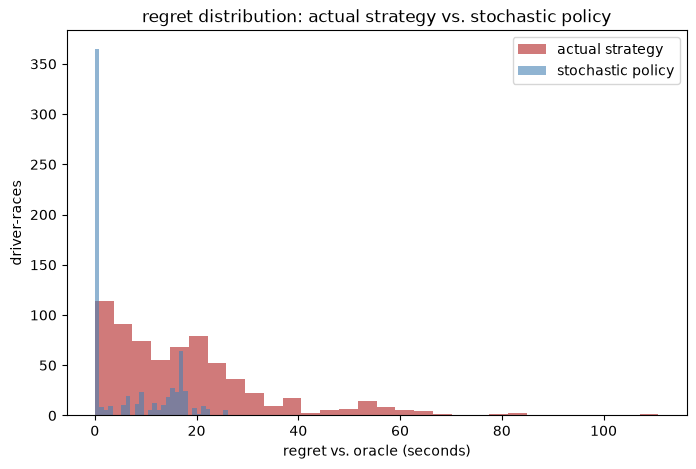

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = 30
ax.hist(report["actual_regret_seconds"], bins=bins, alpha=0.6, label="actual strategy", color="firebrick")
ax.hist(report["policy_regret_seconds"], bins=bins, alpha=0.6, label="stochastic policy", color="steelblue")
ax.set_xlabel("regret vs. oracle (seconds)")
ax.set_ylabel("driver-races")
ax.set_title("regret distribution: actual strategy vs. stochastic policy")
ax.legend()
plt.show()

In [4]:
circuit_summary = (
    report.groupby("circuit_id")[["actual_regret_seconds", "policy_regret_seconds"]]
    .agg(["mean", "count"])
    .sort_values(("actual_regret_seconds", "mean"), ascending=False)
)
circuit_summary

actual_regret_seconds       policy_regret_seconds      
                               mean count                  mean count
circuit_id                                                           
nurburgring               63.141000     1              0.100000     1
zandvoort                 48.156137     8              2.591900     8
imola                     45.255329    14              9.874671    14
losail                    36.492364     7             19.809650     7
interlagos                33.371900     3              3.575233     3
monaco                    31.705800    20              1.721300    20
marina_bay                30.178088    34             10.612971    34
villeneuve                27.670667    15              3.472000    15
albert_park               22.889786    21              2.132833    21
sochi                     22.361875    12             10.650146    12
bahrain                   22.003995    19              5.308432    19
red_bull_ring             21.003953    29              0.671316    29
rodriguez                 17.593121    29              3.726845    29
shanghai                  16.414546    26              5.122508    26
vegas                     15.820168    19             15.112232    19
hungaroring               15.801375    20              0.071000    20
baku                      15.299640    40              9.235790    40
miami                     14.774282    44              7.943445    44
ricard                    13.744568    25              8.461688    25
monza                     13.296344    57              7.740456    57
silverstone               13.292439    31             10.134903    31
suzuka                    13.142597    33              8.947173    33
portimao                  12.095000     4              0.000000     4
spa                       11.844568    38              3.702232    38
americas                  10.291736    21              0.198536    21
catalunya                  7.563750     8              0.000000     8
jeddah                     7.412800    45              6.635822    45
yas_marina                 5.574035    43              3.004088    43